In [1]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator

- **Alice's state**: array of 0s and 1s denoting the state to be encoded
- **Alice's bases**: array of 0s and 1s denoting the basis to be used for encoding
  - 0 → Computational Basis
  - 1 → Hadamard Basis
- **Bob's bases**: array of 0s and 1s denoting the basis to be used for measurement
  - 0 → Computational Basis
  - 1 → Hadamard Basis

In [2]:
num_qubits = 16

alice_basis = np.random.randint(2, size=num_qubits)
alice_state = np.random.randint(2, size=num_qubits)
bob_basis = np.random.randint(2, size=num_qubits)

print(f"Alice's State:\t {np.array2string(alice_state)}")
print(f"Alice's Bases:\t {np.array2string(alice_basis)}")
print(f"Bob's Bases:\t {np.array2string(bob_basis)}")      

Alice's State:	 [1 1 0 1 0 1 0 1 0 0 0 0 0 0 0 1]
Alice's Bases:	 [0 1 1 0 0 1 1 1 0 1 0 0 0 1 1 0]
Bob's Bases:	 [0 0 0 1 1 1 0 0 0 0 1 0 0 1 0 0]


In [4]:
num_qubits = len(alice_state)

circuit = QuantumCircuit(num_qubits)

# Sender prepares qubits
for i in range(len(alice_basis)):
    if alice_state[i] == 1:
        circuit.x(i)
    if alice_basis[i] == 1:
        circuit.h(i)


# Measuring action performed by Bob
for i in range(len(bob_basis)):
    if bob_basis[i] == 1:
        circuit.h(i)

circuit.measure_all()

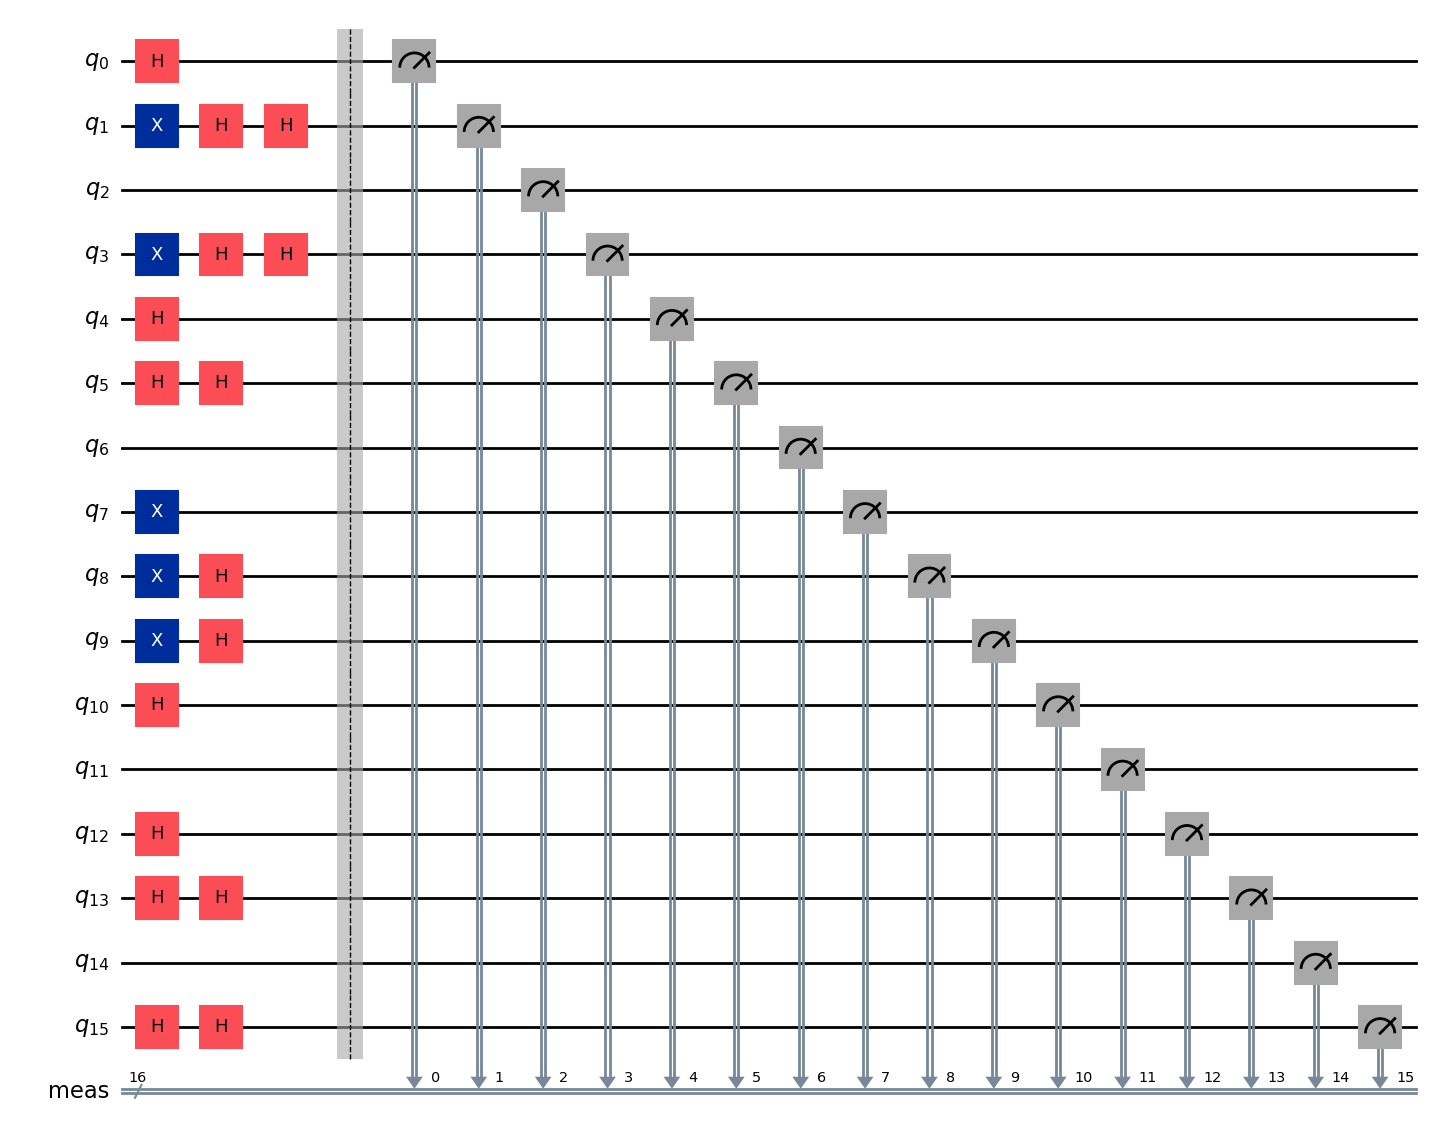

In [5]:
circuit.draw('mpl')

In [10]:
simulator = AerSimulator()

In [23]:
job = simulator.run(circuit, shots=1)

In [24]:
result = job.result()

In [25]:
counts = result.get_counts()

In [26]:
key = counts.most_frequent()

In [27]:
encryption_key = ''
for i in range(num_qubits):
    if alice_basis[i] == bob_basis[i]:
         encryption_key += str(key[i])
print(f"Key: {encryption_key}")

Key: 0001111011
